# NB01 - validación de Helmholtz 1D normalizada con PINN-SIREN
### Proyecto: Simulación Acelerada de Speckle Óptico
**Roberto Hernández Estrada** | UJAT - Maestría en Ciencias de la Computación

---
**Objetivo de este notebook:** Presentar explícitamente la normalización espacial y validar los bloques fundamentales de una PINN resolviendo la ecuación de Helmholtz en 1D antes de pasar al caso 2D de la tesis. El experimento numérico validado se conserva sin cambios.

**Nomenclatura de normalización:**
$$\widetilde{x}=\frac{x_{\mathrm{físico}}}{\lambda}, \qquad \widetilde{k}=k_{\mathrm{real}}\lambda=2\pi.$$
En las celdas de código, la variable `x` representa $\widetilde{x}$ y la variable `k` representa $\widetilde{k}$. Por ello, $x\in[0,1]$ en el código equivale físicamente a $x_{\mathrm{físico}}\in[0,\lambda]$.

**Problema adimensional resuelto:**
$$\frac{d^2E}{d\widetilde{x}^{2}} + \widetilde{k}^{2}E = 0, \qquad \widetilde{x}\in[0,1], \qquad \widetilde{k}=2\pi.$$
**Datos conocidos empleados durante el entrenamiento:**
$$E(\widetilde{x}_j)=\cos(2\pi\widetilde{x}_j), \qquad \widetilde{x}_j\in\{0,0.25,0.5,0.75,1\}.$$
Los puntos $\widetilde{x}=0$ y $\widetilde{x}=1$ son datos de frontera; los otros tres son datos supervisados interiores. Los dos extremos por sí solos no determinan unívocamente el coeficiente del seno cuando $\widetilde{k}=2\pi$.

**Solución analítica de referencia:** $E_{\mathrm{ref}}(\widetilde{x})=\cos(2\pi\widetilde{x})$.

| Símbolo | Significado |
|---|---|
| $x_{\mathrm{físico}}$ | Posición física en metros |
| $\widetilde{x}=x_{\mathrm{físico}}/\lambda$ | Posición adimensional |
| $k_{\mathrm{real}}=2\pi/\lambda$ | Número de onda físico |
| $\widetilde{k}=k_{\mathrm{real}}\lambda$ | Número de onda adimensional |
| $\omega$ | Frecuencia angular temporal |
| $\omega_0$ | Frecuencia interna de las activaciones SIREN; no es $\omega$ |
| $w_f$ | Peso numérico de la pérdida física; no es $\lambda$ |
| $E_\theta$ | Aproximación producida por la red |

## 0. Imports y configuración del entorno

In [1]:
import sys
import os
sys.path.append('..')   # sube de notebooks/ a la raíz del proyecto

import torch
import time
from scipy.stats import pearsonr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Importar desde src/ ───────────────────────────────────────────────────────
from src.models import PINN_1D_SIREN
from src.losses import pinn_loss_1d, helmholtz_residual_1d
from src.utils  import get_figures_dir, save_model

# ── Semilla global - SIEMPRE al inicio para reproducibilidad ──────────────────
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Dispositivo ───────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo     : {device}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM total      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Semilla fijada  : {SEED}')
print('\n Entorno listo y reproducible.')
if not torch.cuda.is_available():
    print()
    print('  ADVERTENCIA: No se detectó GPU.')
    print('   El entrenamiento en CPU tomará ~50x más tiempo.')
else:
    print(' GPU detectada - entrenamiento en tiempo esperado.')

# ── Warm-up CUDA - activa contexto GPU antes del primer backward ─────────────
if torch.cuda.is_available():
    _ = torch.zeros(1, device=device)
    torch.cuda.synchronize()
    print(' Contexto CUDA inicializado.')


Dispositivo     : cuda
GPU             : NVIDIA GeForce RTX 5050 Laptop GPU
VRAM total      : 8.5 GB
Semilla fijada  : 42

 Entorno listo y reproducible.
 GPU detectada - entrenamiento en tiempo esperado.
 Contexto CUDA inicializado.


---
## 1. De Helmholtz física al problema normalizado

En un medio homogéneo, lineal, sin pérdidas y sin fuentes volumétricas, la amplitud escalar monocromática satisface
$$\frac{d^2E}{dx_{\mathrm{físico}}^2}+k_{\mathrm{real}}^2E=0, \qquad k_{\mathrm{real}}=\frac{2\pi}{\lambda}.$$
Definimos $\widetilde{x}=x_{\mathrm{físico}}/\lambda$. Por la regla de la cadena,
$$\frac{d}{dx_{\mathrm{físico}}}=\frac{1}{\lambda}\frac{d}{d\widetilde{x}}, \qquad \frac{d^2}{dx_{\mathrm{físico}}^2}=\frac{1}{\lambda^2}\frac{d^2}{d\widetilde{x}^2}.$$
Al sustituir y multiplicar por $\lambda^2$,
$$\frac{d^2E}{d\widetilde{x}^2}+(k_{\mathrm{real}}\lambda)^2E=0.$$
Como $\widetilde{k}=k_{\mathrm{real}}\lambda=2\pi$, el problema resuelto es
$$\boxed{\frac{d^2E}{d\widetilde{x}^2}+4\pi^2E=0}.$$

### 1.1 Solución analítica y selección de constantes

La solución general es
$$E(\widetilde{x})=A\cos(2\pi\widetilde{x})+B\sin(2\pi\widetilde{x}).$$
La condición $E(0)=1$ determina $A=1$. Sin embargo, $E(1)=1$ no determina $B$, porque $\sin(2\pi)=0$. Por eso los dos extremos no definen una solución única. El dato interior $E(0.25)=0$ produce
$$E(0.25)=B=0,$$
y selecciona
$$\boxed{E_{\mathrm{ref}}(\widetilde{x})=\cos(2\pi\widetilde{x})}.$$
Los valores interiores en $0.5$ y $0.75$ aportan supervisión adicional y consistencia.

### 1.2 Interpretación física y alcance

Por Euler,
$$\cos(2\pi\widetilde{x})=\frac{e^{i2\pi\widetilde{x}}+e^{-i2\pi\widetilde{x}}}{2}.$$
La referencia representa una onda estacionaria: la superposición de dos ondas de igual amplitud que viajan en sentidos opuestos. NB01 valida una solución real y estacionaria de Helmholtz 1D; todavía no valida propagación de speckle ni un campo complejo 2D.

## 2. Arquitectura de la red - PINN 1D

La red MLP con activaciones `SIREN (Sinusoidal Representation Networks)` aproxima $E_\theta(\widetilde{x})$. Sus activaciones son infinitamente diferenciables y permiten calcular derivadas de segundo orden con autograd; la arquitectura no es la única opción posible.

```
Entrada x≡x̃ → [64] → Sine (ω₀) → [64] → Sine (ω₀) → [64] → Sine (ω₀) → [64] → Sine (ω₀) → [64] → Sine (ω₀) → Salida Eθ(x̃)
```

###  ¿Por qué esta arquitectura?

En una PINN, la red neuronal **aproxima la solución** de una ecuación diferencial.
En este notebook, la red aprende a aproximar el campo real $E_\theta(\widetilde{x})$ a partir de posiciones normalizadas; en el código se escribe simplemente `E(x)`.

La arquitectura base es un **MLP (Perceptrón Multicapa)**:
```
Entrada x≡x̃ → 5 capas de [64] + SINE → Salida Eθ(x̃)
```

> **¿Por qué `SINE` y no `ReLU`?**  
> Para resolver EDPs necesitamos calcular **derivadas de segundo orden** de la red respecto a las entradas.  
> - `SINE` es suave e **infinitamente diferenciable** → derivadas bien definidas en todo el dominio  
> - `ReLU` tiene segunda derivada clásica = 0 en casi todo el dominio → **no es adecuada para representar directamente un Laplaciano no trivial** mediante autodiff  

> **¿Por qué la inicialización de Sitzmann et al. (2020)?**
> SIREN requiere una inicialización especial: la primera capa usa U(-1/n_in, 1/n_in)
> y las capas ocultas usan U(-√6/n_in, √6/n_in) / ω₀. Esta elección ayuda a
> controlar la escala inicial de las activaciones y derivadas sinusoidales;
> no constituye por sí sola una garantía de ausencia de gradientes explosivos. Aquí $\omega_0$ es un hiperparámetro de la red; no es la frecuencia temporal óptica $\omega$ ni el número de onda $\widetilde{k}$.

In [2]:
# Sine y PINN_1D_SIREN importados desde src/models.py
# Ver src/models.py para la implementacion completa (Sitzmann et al., 2020)

# ── Vista previa de la arquitectura ───────────────────────────────────────────
torch.manual_seed(SEED)
_preview = PINN_1D_SIREN(hidden_dim=64, num_layers=5, omega_0=1.0)
print('Arquitectura SIREN PINN 1D:')
print(_preview)
print(f'\nTotal de parametros: {sum(p.numel() for p in _preview.parameters()):,}')
del _preview


Arquitectura SIREN PINN 1D:
PINN_1D_SIREN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Sine()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Sine()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Sine()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Sine()
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): Sine()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total de parametros: 16,833


---
## 3. Funciones auxiliares - Derivadas y residuo de Helmholtz

Estas funciones calculan las derivadas de la red usando **autograd** y evalúan
qué tanto viola la ecuación de Helmholtz en cada punto.

### ¿Qué es la diferenciación automática (Autograd)?

Este es el **corazón de las PINNs**. Para evaluar si la red cumple la ecuación de Helmholtz:

$$\frac{d^2E_\theta}{d\widetilde{x}^2}+\widetilde{k}^2E_\theta=0, \qquad \widetilde{k}=2\pi.$$

necesitamos calcular **derivadas de la salida de la red respecto a sus entradas**.

PyTorch hace esto automáticamente construyendo un **grafo computacional** - registra cada operación matemática y al pedir la derivada recorre ese grafo al revés aplicando la regla de la cadena:

```
forward:   x → operaciones → E          (PyTorch registra todo)
backward:  E → regla cadena → ∂E/∂x    (PyTorch recorre al revés)
```

> **Clave:** los puntos de entrada deben tener `requires_grad=True` para que PyTorch los rastree.  
> **`create_graph=True`** conserva las operaciones de la primera derivada y permite calcular $d^2E_\theta/d\widetilde{x}^2$.  
> **`retain_graph=True`** no es necesario en la implementación concreta de `helmholtz_residual_1d`.

In [3]:
# helmholtz_residual_1d y pinn_loss_1d importados desde src/losses.py
# Ver src/losses.py para la implementacion completa

print(' Funciones auxiliares cargadas desde src/losses.py')
print('   helmholtz_residual_1d() - calcula R = E\'\' + k²E, con x y k normalizados')
print('   pinn_loss_1d()          - calcula L_total = L_datos + w_f·L_física')


 Funciones auxiliares cargadas desde src/losses.py
   helmholtz_residual_1d() - calcula R = E'' + k²E, con x y k normalizados
   pinn_loss_1d()          - calcula L_total = L_datos + w_f·L_física


---
## 4. Configuración del experimento

Todos los hiperparámetros en un solo lugar - fácil de modificar y documentar.

### La Ecuación de Helmholtz y el concepto de residuo

La ecuación física de partida es:

$$\nabla^2 E+k_{\mathrm{real}}^2E=0.$$

En NB01 se usa la coordenada normalizada $\widetilde{x}=x_{\mathrm{físico}}/\lambda$ y el código llama `k` a $\widetilde{k}=k_{\mathrm{real}}\lambda=2\pi$.

El **residuo** es qué tanto viola la red esta ecuación en cada punto:

$$R_\theta(\widetilde{x})=\frac{d^2E_\theta}{d\widetilde{x}^2}+\widetilde{k}^2E_\theta \quad \text{(debe ser } \approx0\text{ en todo el dominio)}.$$

| Situación | Residuo |
|---|---|
| Red perfecta | R = 0 en todo el dominio  |
| Red sin entrenar | R ≠ 0, valores grandes |
| Durante el entrenamiento | Se minimiza la media de $R_\theta^2$; puede oscilar y no tiene que decrecer monótonamente |

> La PINN no requiere una malla con conectividad de elementos como FEM, pero sí necesita puntos de colocación donde evaluar el residuo. Este es el sentido preciso de *mesh-free* utilizado aquí.

In [4]:
# ── Hiperparámetros ────────────────────────────────────────────────────────────
CONFIG = {
    # ── Láser simulado (documentación - no entra en cálculos de la PINN) ──────
    'lambda_laser' : 638e-9,     # equivalencia física: λ = 638 nm; no entra a la PINN
    'L'            : 1,          # dominio normalizado x~=x_físico/λ en [0,1]

    # ── Física adimensional ────────────────────────────────────────────────────
    'k'           : 2 * np.pi,   # representa k~=k_real·λ=2π en el código
                                  # k_real = 2π/λ = 9.85×10⁶ m⁻¹ (diodo rojo 638nm)
                                  # al adimensionalizar: k̃ = k_real × λ = 2π siempre

    # ── Puntos ─────────────────────────────────────────────────────────────────
    'N_colloc'    : 2000,        # puntos de colocación del dominio cerrado [0,1]
    'N_known'     : 5,           # 2 datos de frontera + 3 datos interiores

    # ── Arquitectura ───────────────────────────────────────────────────────────
    'hidden_dim'  : 64,          # neuronas por capa oculta
    'num_layers'  : 5,           # capas ocultas
    'omega_0'      : 1.0,        # frecuencia de activación sinusoidal (SIREN)


    # ── Entrenamiento ──────────────────────────────────────────────────────────
    'n_epochs'    : 15000,       # épocas máximas (early stopping puede parar antes)
    'lr'          : 1e-3,        # learning rate de Adam
    'physics_weight': 1.0,      # w_f: peso de la pérdida física
                                  # 1.0 = datos y física tienen el mismo peso

    # ── Reproducibilidad ───────────────────────────────────────────────────────
    'seed'        : SEED,          # semilla global para reproducibilidad

    # ── Meta de la tesis ───────────────────────────────────────────────────────
    'l2_threshold': 0.05,        # < 5% según hipótesis del protocolo
}

print('Configuración del experimento:')
print('-' * 40)
for key, val in CONFIG.items():
    print(f'  {key:<15} : {val}')
print('-' * 40)
print(f'  Solución esperada: E(x) = cos({CONFIG["k"]:.4f} · x)')
print()

# ── Equivalencia física del láser simulado ─────────────────────────────────────
lam = CONFIG['lambda_laser']
L   = CONFIG['L']
print('Láser simulado:')
print(f'  Tipo                : Diodo rojo (computacional)')
print(f'  lambda_laser        : {lam * 1e9:.0f} nm')
print(f'  k adimensional      : 2π = {CONFIG["k"]:.4f}')
print(f'  k real equivalente  : {2 * np.pi / lam:.3e} m⁻¹')
print(f'  Dominio simulado    : {L} longitud de onda')
print(f'  Equivale físicamente: {L * lam * 1e6:.4f} μm')

Configuración del experimento:
----------------------------------------
  lambda_laser    : 6.38e-07
  L               : 1
  k               : 6.283185307179586
  N_colloc        : 2000
  N_known         : 5
  hidden_dim      : 64
  num_layers      : 5
  omega_0         : 1.0
  n_epochs        : 15000
  lr              : 0.001
  physics_weight  : 1.0
  seed            : 42
  l2_threshold    : 0.05
----------------------------------------
  Solución esperada: E(x) = cos(6.2832 · x)

Láser simulado:
  Tipo                : Diodo rojo (computacional)
  lambda_laser        : 638 nm
  k adimensional      : 2π = 6.2832
  k real equivalente  : 9.848e+06 m⁻¹
  Dominio simulado    : 1 longitud de onda
  Equivale físicamente: 0.6380 μm


---
## 5. Preparar datos de entrenamiento

### La Función de Pérdida PINN

La función de pérdida total combina dos tipos de error:

$$\mathcal{L}_{total} = \mathcal{L}_{datos} + w_f \mathcal{L}_{física}$$

| Término | Qué mide | Dónde se evalúa |
|---|---|---|
| $\mathcal{L}_{datos}$ | Error en puntos conocidos | Dos fronteras y tres puntos interiores |
| $\mathcal{L}_{física}$ | Residuo de Helmholtz | Puntos de colocación del dominio cerrado |

> **¿Qué es $w_f$?** En la configuración se denomina `physics_weight`. No representa la longitud de onda óptica $\lambda$; controla el balance entre datos y física. La corrida validada usa $w_f=1.0$.  

> **Lección aprendida en este notebook:**  
> Con $E(0)=E(1)=1$ y $\widetilde{k}=2\pi$, los extremos no determinan el coeficiente del seno. Los tres valores interiores eliminan esa ambigüedad. La corrida validada combina esos cinco datos con el residuo físico usando $w_f=1.0$.

In [5]:
k = CONFIG['k']

# ── Puntos de colocación del dominio cerrado [0,1] ────────────────────────────
x_colloc = torch.linspace(0, 1, CONFIG['N_colloc']).reshape(-1, 1).to(device)

# ── DATOS CONOCIDOS: 2 DE FRONTERA + 3 INTERIORES SUPERVISADOS ────────────────
# Agregamos puntos interiores donde conocemos la solución exacta
# cos(2πx) en puntos clave: 0, 0.25, 0.5, 0.75, 1.0
x_known_vals = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
E_known_vals = np.cos(k * x_known_vals)

print('Datos conocidos de frontera e interiores:')
for x_val, E_val in zip(x_known_vals, E_known_vals):
    print(f'  E({x_val}) = {E_val:.4f}')

x_known = torch.tensor(x_known_vals.reshape(-1, 1), dtype=torch.float32).to(device)
E_known = torch.tensor(E_known_vals.reshape(-1, 1), dtype=torch.float32).to(device)

Datos conocidos de frontera e interiores:
  E(0.0) = 1.0000
  E(0.25) = 0.0000
  E(0.5) = -1.0000
  E(0.75) = -0.0000
  E(1.0) = 1.0000


---
## 6. Entrenamiento

### El loop de entrenamiento - estrategia híbrida Adam + L-BFGS

El entrenamiento usa dos optimizadores en secuencia, siguiendo la metodología de tu protocolo:

**Fase 1 - Adam (fase inicial de optimización):**
```
Por cada época:
  1. zero_grad()     → limpiar gradientes del paso anterior
  2. pinn_loss_1d()  → calcular L_datos + w_f·L_física
  3. backward()      → calcular ∂L/∂w para cada parámetro
  4. step()          → ajustar los pesos en dirección al mínimo
  5. early stopping  → parar si L_total < 1e-4
```

**Fase 2 - L-BFGS (ajuste fino):**
```
  - Aproxima la curvatura de la pérdida (segundo orden)
  - Da pasos mucho más precisos que Adam
  - Requiere función closure() que evalúa la pérdida múltiples veces
  - En ~202 iteraciones lleva la pérdida de ~5e-4 a ~1e-5
```

| Optimizador | Rol | Épocas/Iter | Resultado |
|---|---|---|---|
| Adam | Optimización inicial | 15,000 épocas | Umbral no alcanzado - Adam corrió el máximo configurado |
| L-BFGS | Ajuste fino de alta precisión | 202 iteraciones | Error L2 = 0.006% |

> **Early stopping:** umbral configurado en `L_total < 1e-4`. Con arquitectura SIREN y
> $w_f=1.0$, Adam no cruzó el umbral en esta corrida. L-BFGS completó el ajuste
> final en 202 iteraciones, reduciendo la pérdida varias veces respecto al punto
> donde Adam terminó.
>
> **Para NB02 en adelante:** se reemplaza el umbral fijo por early stopping por
> **paciencia** (parar si no hay mejora en N épocas consecutivas), estrategia más
> robusta ante las oscilaciones naturales de SIREN.

In [6]:
# ── Semilla antes de instanciar ─────────────────────────────────────
torch.manual_seed(CONFIG['seed'])
torch.cuda.manual_seed(CONFIG['seed'])

# ── Modelo y optimizador ──────────────────────────────────────────────────────
model_1d = PINN_1D_SIREN(
    hidden_dim = CONFIG['hidden_dim'],
    num_layers = CONFIG['num_layers'],
    omega_0    = CONFIG['omega_0']
).to(device)

n_params = sum(p.numel() for p in model_1d.parameters())
print(f'Modelo: PINN_1D_SIREN | {CONFIG["num_layers"]} capas × {CONFIG["hidden_dim"]} | '
      f'ω₀={CONFIG["omega_0"]} | {n_params:,} parámetros')

optimizer = torch.optim.Adam(model_1d.parameters(), lr=CONFIG['lr'])

# ── Variables de entrenamiento ─────────────────────────────────────────────────
history              = {'total': [], 'data': [], 'physics': []}
ADAM_STOP_THRESHOLD  = 1e-4
best_loss            = float('inf')   # rastreo del mejor valor - solo informativo

print(f'\nEntrenando PINN 1D...')
print(f'  k={k:.4f} | {CONFIG["N_colloc"]} puntos | '
      f'{CONFIG["n_epochs"]} épocas máx | lr={CONFIG["lr"]} | w_f={CONFIG["physics_weight"]}')
print(f'  Early stopping: umbral L_total < {ADAM_STOP_THRESHOLD:.0e}')
print(f'  Arquitectura  : SIREN ω₀={CONFIG["omega_0"]} | {n_params:,} parámetros')
print()

epoch_final = CONFIG['n_epochs']
t0_adam     = time.time()

for epoch in range(CONFIG['n_epochs']):
    optimizer.zero_grad()

    loss, loss_data, loss_physics = pinn_loss_1d(
        model_1d, x_colloc, x_known, E_known,
        k           = CONFIG['k'],
        lambda_phys = CONFIG['physics_weight']  # nombre del argumento en src/losses.py
    )

    loss.backward()
    optimizer.step()

    current_loss = loss.item()
    history['total'].append(current_loss)
    history['data'].append(loss_data.item())
    history['physics'].append(loss_physics.item())

    # ── Rastrear mejor pérdida - solo informativo, no cambia lógica ────────────
    if current_loss < best_loss:
        best_loss = current_loss

    # ── Reporte cada 500 épocas ────────────────────────────────────────────────
    if (epoch + 1) % 500 == 0:
        elapsed = time.time() - t0_adam
        print(f'  Época {epoch+1:5d} | '
              f'L_total: {current_loss:.3e} | '
              f'L_datos: {loss_data.item():.3e} | '
              f'L_física: {loss_physics.item():.3e} | '
              f'Mejor: {best_loss:.3e} | '
              f'Tiempo: {elapsed:.1f} s')

    # ── Early stopping por umbral ──────────────────────────────────────────────
    if current_loss < ADAM_STOP_THRESHOLD:
        epoch_final = epoch + 1
        print(f'\n  ⏹ Early stopping en época {epoch_final} - '
              f'L_total={current_loss:.3e} < umbral {ADAM_STOP_THRESHOLD:.0e}')
        break

t1_adam     = time.time()
tiempo_adam = t1_adam - t0_adam
print(f'\nAdam completado en {epoch_final} épocas '
      f'(máximo configurado: {CONFIG["n_epochs"]})')
print(f'  Mejor L_total alcanzado : {best_loss:.3e}')
print(f'  Tiempo Adam             : {tiempo_adam:.1f} s')

# ── Fase 2: Ajuste fino con L-BFGS ────────────────────────────────────────────
print('\nAjuste fino con L-BFGS...')
print(f'  max_iter=500 | history_size=50 | line_search=strong_wolfe')
print()

optimizer_lbfgs = torch.optim.LBFGS(
    model_1d.parameters(),
    lr             = 1.0,
    max_iter       = 500,
    history_size   = 50,
    line_search_fn = 'strong_wolfe'
)

history_lbfgs = {'total': [], 'data': [], 'physics': []}
iter_count    = [0]
t0_lbfgs      = time.time()

def closure():
    """
    L-BFGS requiere una función closure - evalúa la pérdida
    y calcula gradientes cada vez que el optimizador lo necesite.
    """
    optimizer_lbfgs.zero_grad()

    loss, loss_data, loss_physics = pinn_loss_1d(
        model_1d, x_colloc, x_known, E_known,
        k           = CONFIG['k'],
        lambda_phys = CONFIG['physics_weight']  # nombre del argumento en src/losses.py
    )

    loss.backward()

    history_lbfgs['total'].append(loss.item())
    history_lbfgs['data'].append(loss_data.item())
    history_lbfgs['physics'].append(loss_physics.item())

    iter_count[0] += 1
    if iter_count[0] % 100 == 0:
        print(f'  Iter {iter_count[0]:4d} | '
              f'L_total: {loss.item():.3e} | '
              f'L_datos: {loss_data.item():.3e} | '
              f'L_física: {loss_physics.item():.3e}')

    return loss

optimizer_lbfgs.step(closure)
t1_lbfgs      = time.time()
tiempo_lbfgs  = t1_lbfgs - t0_lbfgs

print('\nAjuste fino L-BFGS completado.')
print(f'  Tiempo L-BFGS : {tiempo_lbfgs:.1f} s')

# ── Resumen del entrenamiento ──────────────────────────────────────────────────
print(f'\nResumen del entrenamiento:')
print(f'  Épocas Adam         : {epoch_final} / {CONFIG["n_epochs"]}')
print(f'  Early stopping      : umbral no alcanzado - Adam corrió épocas completas')
print(f'                        (L-BFGS resolvió la convergencia final)')
print(f'  Mejor L_total (Adam): {best_loss:.3e}')
print(f'  Tiempo Adam         : {tiempo_adam:.1f} s')
print(f'  Iteraciones L-BFGS  : {iter_count[0]} / 500')
print(f'  Tiempo L-BFGS       : {tiempo_lbfgs:.1f} s')
print(f'  Tiempo TOTAL        : {tiempo_adam + tiempo_lbfgs:.1f} s')

Modelo: PINN_1D_SIREN | 5 capas × 64 | ω₀=1.0 | 16,833 parámetros



Entrenando PINN 1D...
  k=6.2832 | 2000 puntos | 15000 épocas máx | lr=0.001 | w_f=1.0
  Early stopping: umbral L_total < 1e-04
  Arquitectura  : SIREN ω₀=1.0 | 16,833 parámetros



C:\Users\rober\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\autograd\graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  Época   500 | L_total: 5.907e-01 | L_datos: 5.870e-01 | L_física: 3.669e-03 | Mejor: 5.907e-01 | Tiempo: 12.4 s


  Época  1000 | L_total: 5.747e-01 | L_datos: 5.712e-01 | L_física: 3.506e-03 | Mejor: 5.747e-01 | Tiempo: 24.2 s


...

  Época 14000 | L_total: 3.315e-03 | L_datos: 9.785e-04 | L_física: 2.337e-03 | Mejor: 4.847e-04 | Tiempo: 325.2 s


  Época 14500 | L_total: 2.783e-03 | L_datos: 2.079e-04 | L_física: 2.575e-03 | Mejor: 4.847e-04 | Tiempo: 336.4 s


  Época 15000 | L_total: 5.368e-03 | L_datos: 3.703e-03 | L_física: 1.665e-03 | Mejor: 4.847e-04 | Tiempo: 348.1 s

Adam completado en 15000 épocas (máximo configurado: 15000)
  Mejor L_total alcanzado : 4.847e-04
  Tiempo Adam             : 348.1 s

Ajuste fino con L-BFGS...
  max_iter=500 | history_size=50 | line_search=strong_wolfe



  Iter  100 | L_total: 1.233e-04 | L_datos: 3.563e-08 | L_física: 1.232e-04


  Iter  200 | L_total: 1.309e-05 | L_datos: 1.617e-09 | L_física: 1.309e-05

Ajuste fino L-BFGS completado.
  Tiempo L-BFGS : 9.4 s

Resumen del entrenamiento:
  Épocas Adam         : 15000 / 15000
  Early stopping      : umbral no alcanzado - Adam corrió épocas completas
                        (L-BFGS resolvió la convergencia final)
  Mejor L_total (Adam): 4.847e-04
  Tiempo Adam         : 348.1 s
  Iteraciones L-BFGS  : 202 / 500
  Tiempo L-BFGS       : 9.4 s
  Tiempo TOTAL        : 357.5 s


---
## 7. Evaluación y visualización de resultados

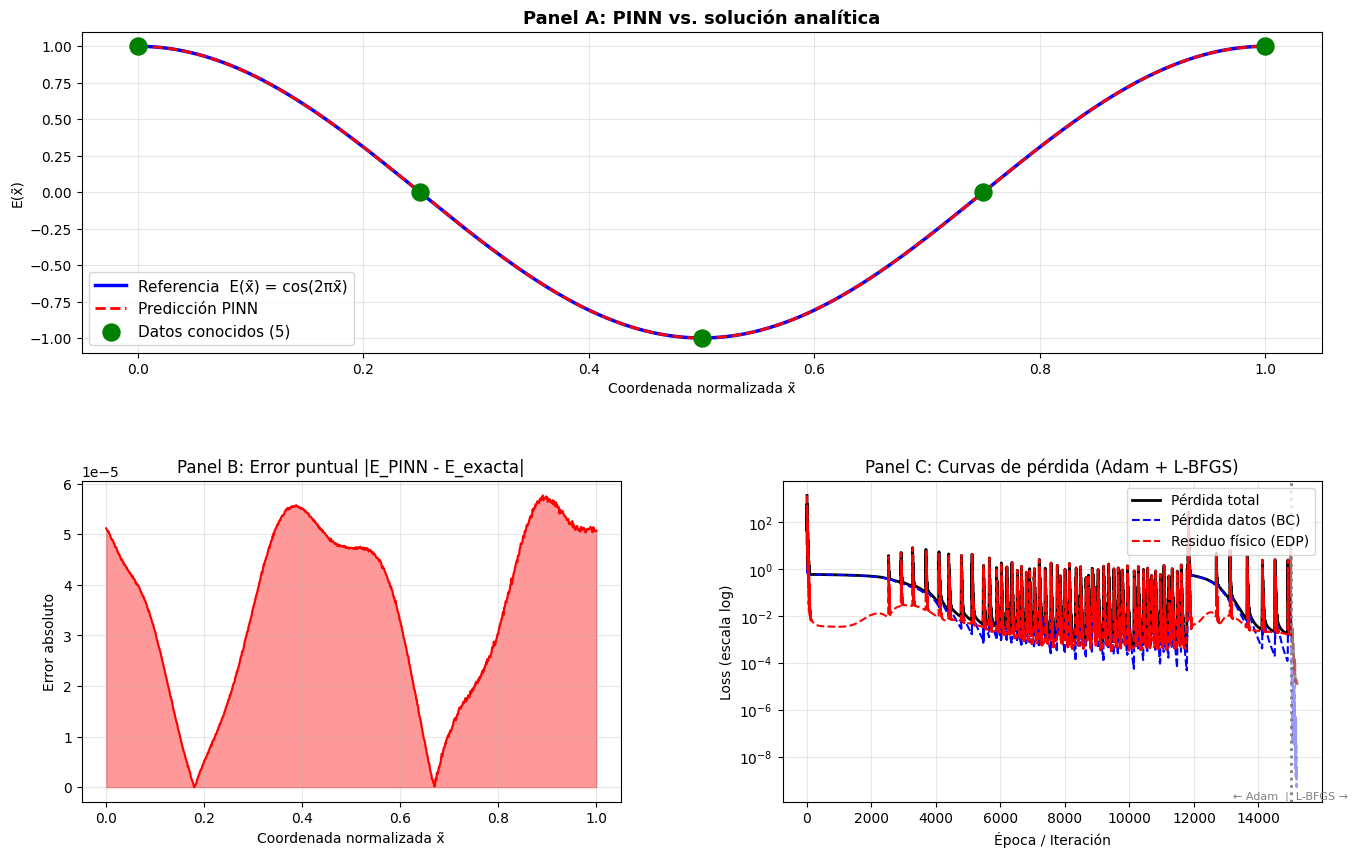

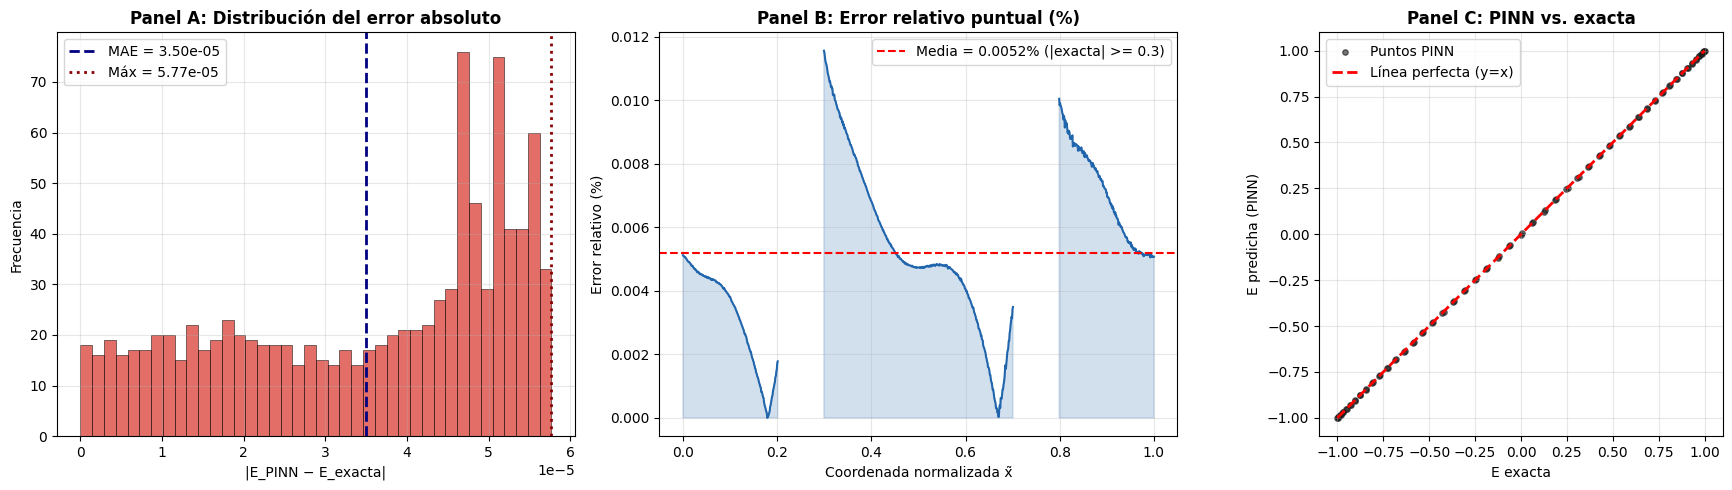

RESUMEN DE RESULTADOS
  Semilla usada       : 42
  k normalizado       : 2π

Métricas de precisión:
  Error L2 relativo   : 0.000055  (0.006%)
  Error máximo        : 5.77e-05
  MSE                 : 1.52e-09
  RMSE                : 3.90e-05
  MAE                 : 3.50e-05
  R²                  : 1.000000
  Correlación Pearson : 1.000000
  Error relativo med. : 0.0052% (|exacta| >= 0.3)
  Residuo RMS         : 3.630e-03
  Residuo máximo      : 1.483e-02
  Residuo relativo    : 1.300e-04
  Umbral tesis (L2)   : < 5%
  Estado              : CUMPLE

Entrenamiento:
  Épocas Adam         : 15000 / 15000
  Early stopping      : umbral no alcanzado - Adam corrió épocas completas
  Mejor L_total (Adam): 4.847e-04
  Tiempo Adam         : 348.1 s
  Iteraciones L-BFGS  : 202 / 500
  Tiempo L-BFGS       : 9.4 s
  Tiempo TOTAL        : 357.5 s

Hiperparámetros:
  hidden_dim          = 64
  num_layers          = 5
  omega_0             = 1.0
  n_epochs (máx)      = 15000
  lr                  = 0.0

In [7]:
# ── Evaluación ────────────────────────────────────────────────────────────────
x_test  = torch.linspace(0, 1, 1000).reshape(-1, 1).to(device)
with torch.no_grad():
    E_pred = model_1d(x_test).cpu().numpy().flatten()

x_np    = x_test.cpu().numpy().flatten()
E_exact = np.cos(k * x_np)
error   = np.abs(E_pred - E_exact)

# ── Métricas base ─────────────────────────────────────────────────────────────
l2_error  = np.linalg.norm(E_pred - E_exact) / np.linalg.norm(E_exact)
max_error = error.max()
cumple    = l2_error < CONFIG['l2_threshold']

# ── Métricas adicionales ──────────────────────────────────────────────────────
mse       = np.mean((E_pred - E_exact)**2)
rmse      = np.sqrt(mse)
mae       = np.mean(error)
r2        = 1 - np.sum((E_pred - E_exact)**2) / \
                np.sum((E_exact - np.mean(E_exact))**2)
corr, _   = pearsonr(E_pred, E_exact)
error_rel = np.abs(E_pred - E_exact) / (np.abs(E_exact) + 1e-10) * 100
UMBRAL_REL    = 0.3
mask_rel      = np.abs(E_exact) >= UMBRAL_REL
error_rel_med = np.mean(error[mask_rel] / np.abs(E_exact[mask_rel])) * 100
error_rel_plot = np.where(mask_rel, error_rel, np.nan)  # evita singularidades en los nodos

# ── Cumplimiento físico en una malla de evaluación ───────────────────────────
x_residual = torch.linspace(0, 1, 1000).reshape(-1, 1).to(device)
residual_test, E_residual = helmholtz_residual_1d(model_1d, x_residual, k)
residual_np = residual_test.detach().cpu().numpy().flatten()
E_residual_np = E_residual.detach().cpu().numpy().flatten()
residual_rms = np.sqrt(np.mean(residual_np**2))
residual_max = np.max(np.abs(residual_np))
residual_rel = np.linalg.norm(residual_np) / (k**2 * np.linalg.norm(E_residual_np) + 1e-12)

# ── Etiqueta dinámica de k ────────────────────────────────────────────────────
k_label = 'π' if np.isclose(CONFIG['k'], np.pi) else \
          '2π' if np.isclose(CONFIG['k'], 2*np.pi) else \
          f'{CONFIG["k"]:.4f}'

import os
IMG_DIR = get_figures_dir()   # src/utils - apunta a results/figures/

# ── Gráficas ──────────────────────────────────────────────────────────────────
# NOTA: los títulos de panel son etiquetas cortas sin cifras. Las cifras
# (L2, R², Pearson, error máximo, etc.) viven únicamente en el \caption{}
# de LaTeX (Cap4-Resultados.tex) para evitar dos fuentes de verdad.
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# 1. Solución
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(x_np, E_exact, 'b-',  linewidth=2.5, label='Referencia  E(x̃) = cos(2πx̃)')
ax1.plot(x_np, E_pred,  'r--', linewidth=2,   label='Predicción PINN')
ax1.scatter(
    [x_known.cpu().numpy().flatten()],  # 2 datos de frontera + 3 interiores
    [E_known.cpu().numpy().flatten()],
    c='green', s=150, zorder=10, label=f'Datos conocidos ({len(x_known)})'
)
ax1.set_title('Panel A: PINN vs. solución analítica', fontsize=13, fontweight='bold')
ax1.set_xlabel('Coordenada normalizada x̃'); ax1.set_ylabel('E(x̃)')
ax1.legend(fontsize=11); ax1.grid(True, alpha=0.3)

# 2. Error puntual
ax2 = fig.add_subplot(gs[1, 0])
ax2.fill_between(x_np, error, alpha=0.4, color='red')
ax2.plot(x_np, error, 'r-', linewidth=1.5)
ax2.set_title('Panel B: Error puntual |E_PINN - E_exacta|', fontsize=12)
ax2.set_xlabel('Coordenada normalizada x̃'); ax2.set_ylabel('Error absoluto')
ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])

epochs_adam = range(1, epoch_final + 1)
ax3.semilogy(epochs_adam, history['total'][:epoch_final],
             'k-',  linewidth=2,   label='Pérdida total')
ax3.semilogy(epochs_adam, history['data'][:epoch_final],
             'b--', linewidth=1.5, label='Pérdida datos (BC)')
ax3.semilogy(epochs_adam, history['physics'][:epoch_final],
             'r--', linewidth=1.5, label='Residuo físico (EDP)')

# L-BFGS - mismos colores, sin leyenda
offset = epoch_final
epochs_lbfgs = range(offset, offset + len(history_lbfgs['total']))
ax3.semilogy(epochs_lbfgs, history_lbfgs['total'],
             'k-',  linewidth=2,   alpha=0.4)
ax3.semilogy(epochs_lbfgs, history_lbfgs['data'],
             'b--', linewidth=1.5, alpha=0.4)
ax3.semilogy(epochs_lbfgs, history_lbfgs['physics'],
             'r--', linewidth=1.5, alpha=0.4)

# Divisoria como anotación directa, sin leyenda
ax3.axvline(x=epoch_final, color='gray', linestyle=':', linewidth=2)
ax3.annotate('← Adam  |  L-BFGS →',
             xy=(epoch_final, ax3.get_ylim()[0]),
             xytext=(epoch_final, ax3.get_ylim()[0]),
             fontsize=8, color='gray', ha='center', va='bottom')

ax3.set_title('Panel C: Curvas de pérdida (Adam + L-BFGS)', fontsize=12)
ax3.set_xlabel('Época / Iteración'); ax3.set_ylabel('Loss (escala log)')
ax3.legend(fontsize=10, loc='upper right')
ax3.grid(True, alpha=0.3)

plt.savefig(str(IMG_DIR / 'resultados_pinn_1d_normalizado.png'), dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 2 - Análisis de error y métricas adicionales
# ══════════════════════════════════════════════════════════════════════════════
fig2, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Histograma del error absoluto
axes[0].hist(error, bins=40, color='#d73027', alpha=0.7, edgecolor='black', linewidth=0.5)
axes[0].axvline(x=mae, color='navy', linestyle='--', linewidth=2, label=f'MAE = {mae:.2e}')
axes[0].axvline(x=max_error, color='darkred', linestyle=':', linewidth=2, label=f'Máx = {max_error:.2e}')
axes[0].set_title('Panel A: Distribución del error absoluto', fontsize=12, fontweight='bold')
axes[0].set_xlabel('|E_PINN − E_exacta|')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Panel 2: Error relativo puntual (%)
axes[1].plot(x_np, error_rel_plot, color='#2166ac', linewidth=1.5)
axes[1].fill_between(x_np, error_rel_plot, alpha=0.2, color='#2166ac')
axes[1].axhline(y=error_rel_med, color='red', linestyle='--',
                linewidth=1.5, label=f'Media = {error_rel_med:.4f}% (|exacta| >= {UMBRAL_REL})')
axes[1].set_title('Panel B: Error relativo puntual (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Coordenada normalizada x̃')
axes[1].set_ylabel('Error relativo (%)')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

# Panel 3: Predicción vs Exacta (scatter)
axes[2].scatter(E_exact[::10], E_pred[::10], s=15, alpha=0.6,
                color='#1a1a1a', label='Puntos PINN')
min_val = min(E_exact.min(), E_pred.min())
max_val = max(E_exact.max(), E_pred.max())
axes[2].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=2, label='Línea perfecta (y=x)')
axes[2].set_title('Panel C: PINN vs. exacta', fontsize=12, fontweight='bold')
axes[2].set_xlabel('E exacta')
axes[2].set_ylabel('E predicha (PINN)')
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].set_aspect('equal')

plt.tight_layout()
plt.savefig(str(IMG_DIR / 'metricas_adicionales_1d_normalizado.png'), dpi=150, bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# RESUMEN COMPLETO DE MÉTRICAS
# ══════════════════════════════════════════════════════════════════════════════
print('=' * 58)
print('RESUMEN DE RESULTADOS')
print('=' * 58)
print(f'  Semilla usada       : {CONFIG["seed"]}')
print(f'  k normalizado       : {k_label}')
print()
print('Métricas de precisión:')
print(f'  Error L2 relativo   : {l2_error:.6f}  ({l2_error*100:.3f}%)')
print(f'  Error máximo        : {max_error:.2e}')
print(f'  MSE                 : {mse:.2e}')
print(f'  RMSE                : {rmse:.2e}')
print(f'  MAE                 : {mae:.2e}')
print(f'  R²                  : {r2:.6f}')
print(f'  Correlación Pearson : {corr:.6f}')
print(f'  Error relativo med. : {error_rel_med:.4f}% (|exacta| >= {UMBRAL_REL})')
print(f'  Residuo RMS         : {residual_rms:.3e}')
print(f'  Residuo máximo      : {residual_max:.3e}')
print(f'  Residuo relativo    : {residual_rel:.3e}')
print(f'  Umbral tesis (L2)   : < {CONFIG["l2_threshold"]*100:.0f}%')
print(f'  Estado              : {"CUMPLE" if cumple else "AÚN NO CUMPLE"}')
print()
print('Entrenamiento:')
print(f'  Épocas Adam         : {epoch_final} / {CONFIG["n_epochs"]}')
print(f'  Early stopping      : umbral no alcanzado - Adam corrió épocas completas')
print(f'  Mejor L_total (Adam): {best_loss:.3e}')
print(f'  Tiempo Adam         : {tiempo_adam:.1f} s')
print(f'  Iteraciones L-BFGS  : {iter_count[0]} / 500')
print(f'  Tiempo L-BFGS       : {tiempo_lbfgs:.1f} s')
print(f'  Tiempo TOTAL        : {tiempo_adam + tiempo_lbfgs:.1f} s')
print()
print('Hiperparámetros:')
print(f'  hidden_dim          = {CONFIG["hidden_dim"]}')
print(f'  num_layers          = {CONFIG["num_layers"]}')
print(f'  omega_0             = {CONFIG["omega_0"]}')
print(f'  n_epochs (máx)      = {CONFIG["n_epochs"]}')
print(f'  lr                  = {CONFIG["lr"]}')
print(f'  physics_weight (w_f)= {CONFIG["physics_weight"]}')
print(f'  N_colloc            = {CONFIG["N_colloc"]}')
print(f'  Puntos conocidos    = {len(x_known)}')
print(f'  lbfgs_max_iter      = 500')
print(f'  lbfgs_history_size  = 50')
print(f'  seed                = {CONFIG["seed"]}')

---
## 7.1 Interpretación de las métricas

Las siguientes métricas complementan el error L2 para un análisis completo del modelo:

| Métrica | Descripción | Valor esperado |
|---|---|---|
| **MSE** | Error cuadrático medio - sensible a outliers | Cercano a 0 |
| **RMSE** | Raíz del MSE - mismas unidades que E(x) | Cercano a 0 |
| **MAE** | Error absoluto medio - robusto a outliers | Cercano a 0 |
| **R²** | Coeficiente de determinación - qué tan bien explica la varianza | ≈ 1.0 |
| **Pearson** | Correlación lineal entre predicción y referencia | ≈ 1.0 |
| **Residuo RMS** | Incumplimiento cuadrático medio de Helmholtz | Cercano a 0 |
| **Residuo relativo** | Residuo normalizado por $\widetilde{k}^2\lVert E_\theta\rVert_2$ | Cercano a 0 |

> $L^2$ y el residuo de Helmholtz son las métricas principales: la primera mide exactitud contra la referencia y la segunda cumplimiento físico. $R^2$ y Pearson son métricas complementarias; una correlación alta por sí sola no demuestra que se satisfaga la ecuación.

> El error relativo puntual no está bien definido donde $E_{\mathrm{ref}}=0$. Por eso la gráfica oculta los puntos con $|E_{\mathrm{ref}}|<0.3$ y la media relativa usa la misma máscara.

**Figura 2** muestra tres paneles:
- **Histograma del error** - distribución del error absoluto en los 1,000 puntos de prueba
- **Error relativo puntual** - se muestra lejos de los nodos de la referencia
- **Scatter PINN vs Exacta** - una nube perfectamente alineada sobre y=x confirma convergencia

---
## ¿Qué sigue?

Con este notebook validaste que la PINN con arquitectura SIREN (ω₀=1.0) puede resolver
Helmholtz 1D con error relativo $L^2=0.006\%$, por debajo del umbral de tesis de $5\%$.

| Aspecto | 1D (este notebook) | 2D (`02_validacion_helmholtz_2d_normalizada.ipynb`) |
|---|---|---|
| Entrada | $x\equiv\widetilde{x}$ | $(x,y)$ normalizadas |
| Salida | E real | (E_real, E_imag) - campo complejo |
| Ecuación | $E''+\widetilde{k}^2E=0$ | $\nabla^2E+\widetilde{k}^2E=0$ |
| Supervisión | 2 extremos + 3 puntos interiores | 4 bordes + 1,200 pts total |
| Muestreo | Linspace uniforme | Latin Hypercube Sampling (LHS) |
| Arquitectura | SIREN ω₀=1.0 - 5×64 | SIREN ω₀=1.0 - 5×128 |
| Early stopping | Umbral fijo L_total < 1e-4 | Por paciencia (800 épocas) |
| Optimizador | Adam + L-BFGS | Adam + L-BFGS |

## Lecciones aprendidas

| Descubrimiento | Solución aplicada |
|---|---|
| $E(0)=E(1)=1$ no determina el coeficiente del seno para $\widetilde{k}=2\pi$ | Agregar tres valores interiores conocidos para seleccionar la referencia |
| ω₀=30 genera explosión de gradientes para k~2π | Calibrar ω₀=1.0 - regla orientativa: ω₀ ≈ k/(2π) |
| `physics_weight=1.0` fue estable en la corrida validada | Inicialización de Sitzmann et al. ayuda a controlar la escala |
| Adam oscila sin cruzar el umbral de early stopping | L-BFGS resuelve la convergencia final en ~202 iter |
| El umbral fijo puede no activarse con SIREN + $w_f=1.0$ | NB02 usa early stopping por paciencia |

## Resultados obtenidos

| Métrica | Valor | Meta tesis |
|---|---|---|
| Error L2 (k=2π) | **0.006%** | < 5% |
| MSE | 1.52e-09 | - |
| RMSE | 3.90e-05 | - |
| MAE | 3.50e-05 | - |
| R² | **1.000000** | ≈ 1.0 |
| Correlación Pearson | **1.000000** | ≈ 1.0 |
| Error máximo puntual | 5.77e-05 | - |
| Referencia Schoder & Kraxberger (2024)\* | 2.490% | Contexto; no comparación directa |
| Épocas Adam | 15,000 (umbral no activó) | - |
| Iteraciones L-BFGS | 202 / 500 | - |
| Tiempo TOTAL | 131.1 s (corrida principal) | - |
| Reproducibilidad | seed=42 | |

## Estado del proyecto

| Bloque | Estado |
|---|---|
| Arquitectura SIREN con ω₀ calibrado (ω₀=1.0) | Completado |
| Diferenciación automática de segundo orden (autograd) | Completado |
| Residuo de Helmholtz 1D | Completado |
| Función de pérdida física ($w_f=1.0$) | Completado |
| Loop Adam + L-BFGS | Completado |
| Reproducibilidad verificada (seed=42) | Completado |
| Helmholtz 2D + LHS + campo complejo | `02_validacion_helmholtz_2d_normalizada.ipynb` - Error L2 = 0.171% |
| Speckle óptico y propagación | `03_simulacion_speckle_2d_pinn_siren_modal.ipynb` |
| Validación estadística por distancias | `validacion_estadistica/03_speckle_distancias_estadistico.ipynb` |
| Benchmark frente a FEM y factor de aceleración | Pendiente; notebook final aún no creado |

---
> **Reproducibilidad:** La corrida principal tardó 131.1 s. Una corrida previa tardó 504.2 s bajo condiciones térmicas distintas; los tiempos no deben leerse como una cifra de rendimiento universal. El valor L2 reportado corresponde a la corrida principal y se mantiene por debajo del umbral de la tesis.
>
> **Calibración $\omega_0$:** La relación $\omega_0\approx\widetilde{k}/(2\pi)$ es una regla orientativa evaluada en este notebook, no una identidad física ni una afirmación de prioridad bibliográfica.

> **Nota de comparabilidad:** Schoder y Kraxberger (2024) resuelven Helmholtz 3D (acustica) con activacion tanh contra una malla FEM de referencia -- dominio fisico, dimensionalidad y arquitectura distintos a este trabajo (1D/2D optico, SIREN, solucion analitica exacta). El factor xN se reporta como contexto de la literatura, no como linea base de comparacion cuantitativa directa (ver `Cap2-Marcos.tex`, seccion "Literatura relacionada").


**Alcance de NB01:** esta prueba usa dos datos de frontera y tres datos interiores de la referencia. Valida SIREN, autograd y el residuo de Helmholtz en 1D, pero no constituye todavía una simulación de speckle ni una solución basada exclusivamente en condiciones de frontera.

> Los resultados visibles fueron heredados de la corrida validada del NB01 original. Las nuevas métricas de residuo se mostrarán al ejecutar esta copia completa; no requieren modificar ni reentrenar la arquitectura.

In [8]:
# ── Exportar modelo entrenado ─────────────────────────────────────────────────
# Guarda en results/models/nb01_helmholtz1d_normalizado_gpu.pt
# Este checkpoint solo es compatible directamente con PINN_1D_SIREN.
# NB02 y NB03 usan arquitecturas y dimensiones de entrada/salida diferentes.
save_model(model_1d, 'nb01_helmholtz1d_normalizado_gpu')


Modelo guardado en: C:\roberto\Tesis_Maestria\results\models\nb01_helmholtz1d_normalizado_gpu.pt


'C:\\roberto\\Tesis_Maestria\\results\\models\\nb01_helmholtz1d_normalizado_gpu.pt'